# Discretización: Euler frente a ZOH exacta
### Circuito RLC

Objetivo: pasar de $\dot x=Ax+Bu$ a $x_{k+1}=A_dx_k+B_du_k$ y observar cómo el periodo de muestreo cambia la precisión y la estabilidad.

Sube este notebook a Colab y selecciona **Entorno de ejecución → Ejecutar todas**. No requiere GPU ni archivos adicionales. Incluye resultados ya calculados.

## 1. El sistema físico

Una fuente $u$ alimenta un inductor $L$ en serie con una rama $R\parallel C$. El estado es $x=[v_C,i_L]^T$ y se observa el voltaje $y=v_C$.

Del balance de corrientes en el nodo del capacitor y del voltaje del inductor:
$$i_L=\frac{v_C}{R}+C\dot v_C,\qquad L\dot i_L=u-v_C.$$
Por tanto:
$$A=\begin{bmatrix}-1/(RC)&1/C\\-1/L&0\end{bmatrix},\qquad
B=\begin{bmatrix}0\\1/L\end{bmatrix},\qquad H=\begin{bmatrix}1&0\end{bmatrix}.$$

Conservaremos $R=1\,\Omega$, $L=1\,\mathrm H$, $C=1\,\mathrm F$, $T=0.5$ s y 100 muestras. La entrada es un escalón de 1 V y el estado inicial es cero. **No hay ruido:** las diferencias provienen únicamente de la discretización.

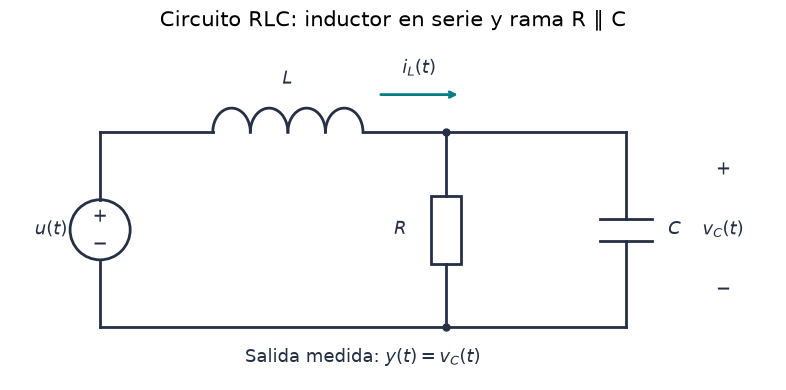

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

fig, ax = plt.subplots(figsize=(10, 4))
color = "#253044"

def cable(x, y):
    ax.plot(x, y, color=color, linewidth=2)

def texto(x, y, contenido):
    ax.text(
        x, y, contenido,
        ha="center", va="center",
        fontsize=13, color=color
    )

# ── Fuente de voltaje ──────────────────────────────────────
ax.add_patch(
    Circle((0, 1.3), 0.4, fill=False, edgecolor=color, linewidth=2)
)
cable([0, 0], [0, 0.9])
cable([0, 0], [1.7, 2.6])
texto(0, 1.47, "+")
texto(0, 1.10, "−")
texto(-0.65, 1.3, r"$u(t)$")

# ── Inductor en serie ──────────────────────────────────────
cable([0, 1.5], [2.6, 2.6])

for j in range(4):
    angulo = np.linspace(np.pi, 0, 50)
    x = 1.75 + 0.5*j + 0.25*np.cos(angulo)
    y = 2.6 + 0.32*np.sin(angulo)
    cable(x, y)

cable([3.5, 7], [2.6, 2.6])
texto(2.5, 3.3, r"$L$")

# Sentido positivo de la corriente del inductor
ax.annotate(
    "", xy=(4.8, 3.1), xytext=(3.7, 3.1),
    arrowprops=dict(arrowstyle="->", color="#007f86", linewidth=2)
)
texto(4.25, 3.45, r"$i_L(t)$")

# ── Resistencia: primera rama en paralelo ──────────────────
cable([4.6, 4.6], [2.6, 1.75])
ax.add_patch(
    Rectangle(
        (4.4, 0.85), 0.4, 0.9,
        fill=False, edgecolor=color, linewidth=2
    )
)
cable([4.6, 4.6], [0.85, 0])
texto(4.0, 1.3, r"$R$")

# ── Capacitor: segunda rama en paralelo ────────────────────
cable([7, 7], [2.6, 1.45])
cable([6.65, 7.35], [1.45, 1.45])  # Placa superior
cable([6.65, 7.35], [1.15, 1.15])  # Placa inferior
cable([7, 7], [1.15, 0])
texto(7.65, 1.3, r"$C$")

# Retorno común a la fuente
cable([0, 7], [0, 0])

# Nodos de conexión
ax.plot([4.6, 4.6], [2.6, 0], "o", color=color, markersize=5)

# Voltaje de salida: polaridad respecto al retorno
texto(8.3, 2.1, "+")
texto(8.3, 1.3, r"$v_C(t)$")
texto(8.3, 0.5, "−")
texto(3.5, -0.4, r"Salida medida: $y(t)=v_C(t)$")

# Presentación
ax.set_title("Circuito RLC: inductor en serie y rama R ∥ C", fontsize=15)
ax.set_xlim(-1.2, 9)
ax.set_ylim(-0.7, 3.9)
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()

# Opcional: guardar la imagen
# fig.savefig("circuito_RLC.png", dpi=300, bbox_inches="tight")

plt.show()

In [20]:
# Instala únicamente las dependencias que falten.
import importlib.util
import subprocess
import sys
missing = [p for p in ("numpy", "scipy", "matplotlib", "pandas")
           if importlib.util.find_spec(p) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.signal import cont2discrete
from IPython.display import display

R, L, C = 1.0, 1.0, 1.0
T, N = 0.5, 100
A = np.array([[-1/(R*C), 1/C], [-1/L, 0.]])
B = np.array([[0.], [1/L]])
H = np.array([[1., 0.]])
x0 = np.zeros(2)
u = np.ones(N)
t = np.arange(N)*T
np.set_printoptions(precision=6, suppress=True)
print(f"Periodo: {T} s; {N} muestras; último instante: {t[-1]} s")

Periodo: 0.5 s; 100 muestras; último instante: 49.5 s


## 2. Dos formas de obtener el modelo discreto

### Euler hacia adelante
Usando $\dot x(t_k)\approx(x_{k+1}-x_k)/T$:
$$x_{k+1}=x_k+T(Ax_k+Bu_k),\qquad
\boxed{A_{d,E}=I+TA,\quad B_{d,E}=TB.}$$
Es una aproximación de primer orden. Un paso pequeño suele reducir el error, pero aumenta el número de pasos necesarios para simular un mismo tiempo físico.

### Exacta con retención de orden cero (ZOH)
Si $u(t)=u_k$ durante $[t_k,t_{k+1})$, la solución del sistema lineal da:
$$\boxed{A_{d,Z}=e^{AT},\qquad B_{d,Z}=\int_0^T e^{A\tau}B\,d\tau.}$$
Es exacta **en los instantes de muestreo**, para el modelo lineal y esa hipótesis de entrada, salvo redondeo numérico. No significa que unir las muestras por segmentos rectos reproduzca exactamente la trayectoria entre muestras.

La fórmula del archivo $B_d=A^{-1}(A_d-I)B$ solo sirve cuando $A$ es invertible. Si $A$ es singular, **no debemos reemplazar $B_d$ por cero**. Una alternativa general calcula ambas matrices a la vez:
$$\exp\left(T\begin{bmatrix}A&B\\0&0\end{bmatrix}\right)
=\begin{bmatrix}A_d&B_d\\0&I\end{bmatrix}.$$
Aquí `expm` es la exponencial **matricial**, no `np.exp`, que actúa elemento a elemento.

In [21]:
def exact_zoh(A, B, T):
    """Discretización ZOH mediante exponencial de una matriz aumentada."""
    if T <= 0:
        raise ValueError("T debe ser positivo")
    n, r = B.shape
    augmented = np.zeros((n+r, n+r))
    augmented[:n, :n] = A
    augmented[:n, n:] = B
    E = expm(T*augmented)
    return E[:n, :n], E[:n, n:]

Ad_euler = np.eye(2) + T*A
Bd_euler = T*B
Ad_exact, Bd_exact = exact_zoh(A, B, T)

print("Euler: Ad =\n", Ad_euler, "\nBd =\n", Bd_euler)
print("\nZOH: Ad =\n", Ad_exact, "\nBd =\n", Bd_exact)
print("\nPrimer estado con Euler:", Bd_euler[:, 0])
print("Primer estado con ZOH:  ", Bd_exact[:, 0])

Euler: Ad =
 [[ 0.5  0.5]
 [-0.5  1. ]] 
Bd =
 [[0. ]
 [0.5]]

ZOH: Ad =
 [[ 0.518249  0.377345]
 [-0.377345  0.895595]] 
Bd =
 [[0.104405]
 [0.481751]]

Primer estado con Euler: [0.  0.5]
Primer estado con ZOH:   [0.104405 0.481751]


**Observa el primer paso:** con los parámetros originales, Euler predice $v_C(T)=0$ porque $\dot v_C(0)=0$. ZOH predice aproximadamente $0.1044$ V: durante ese intervalo ya crece la corriente y empieza a cargar el capacitor. Euler no incorpora ese cambio de pendiente dentro de un mismo paso.

## 3. Simular y comparar

Ambos modelos reciben la misma entrada y condición inicial. En el bucle, `u[k-1]` actúa durante el intervalo que lleva de `x[k-1]` a `x[k]`. Cada fila de los arreglos representa un instante.

Las gráficas se centran en los primeros 10 segundos para ver el transitorio; la tabla de errores utiliza las 100 muestras de la simulación.

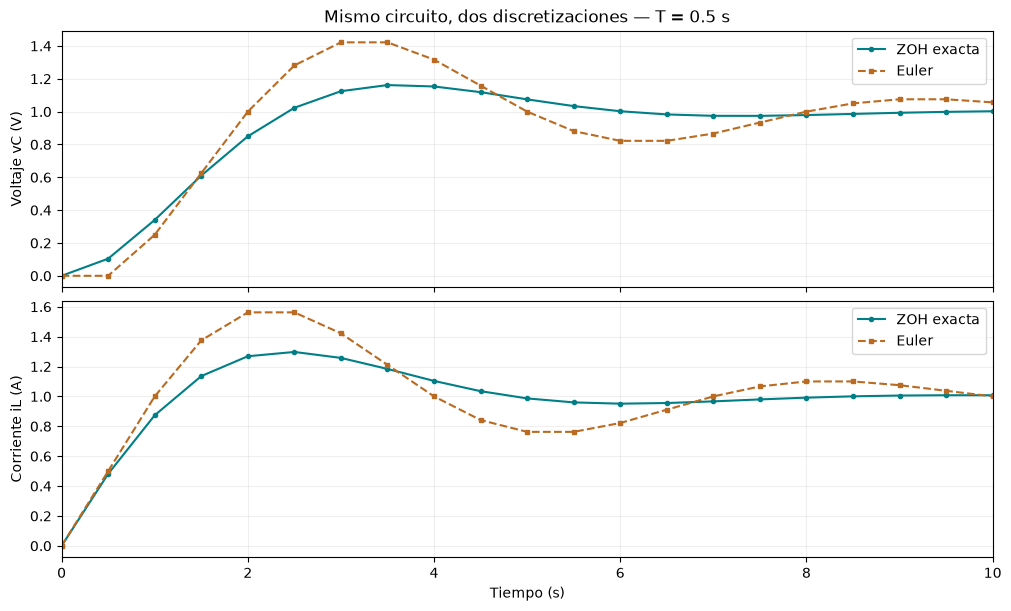

,Estado,RMSE Euler vs ZOH,Error absoluto máximo
0,vC (V),0.064682,0.297520
1,iL (A),0.067632,0.293795


In [22]:
def simulate(Ad, Bd, u, x0):
    X = np.zeros((len(u), len(x0)))
    X[0] = x0
    for k in range(1, len(u)):
        X[k] = Ad @ X[k-1] + Bd[:, 0]*u[k-1]
    return X

X_euler = simulate(Ad_euler, Bd_euler, u, x0)
X_exact = simulate(Ad_exact, Bd_exact, u, x0)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, layout="constrained")
for j, label in enumerate(["Voltaje vC (V)", "Corriente iL (A)"]):
    axes[j].plot(t, X_exact[:,j], "o-", ms=3, color="#007f86", label="ZOH exacta")
    axes[j].plot(t, X_euler[:,j], "s--", ms=3, color="#ba6b21", label="Euler")
    axes[j].set_ylabel(label)
    axes[j].grid(alpha=.2)
    axes[j].legend()
    axes[j].set_xlim(0, min(10, t[-1]))
axes[0].set_title(f"Mismo circuito, dos discretizaciones — T = {T:g} s")
axes[-1].set_xlabel("Tiempo (s)")
plt.show()

error = X_euler-X_exact
metrics = pd.DataFrame({
    "Estado": ["vC (V)", "iL (A)"],
    "RMSE Euler vs ZOH": np.sqrt(np.mean(error**2, axis=0)),
    "Error absoluto máximo": np.max(np.abs(error), axis=0)})
display(metrics.round(6))

**Qué interpretar:** con $T=0.5$ s ambos modelos son estables, pero Euler altera el amortiguamiento y el transitorio. Ambos convergen al mismo equilibrio, $v_C=1$ V e $i_L=1$ A. Coincidir en el valor final **no demuestra** que sus trayectorias sean iguales.

El RMSE sobre un horizonte largo puede ocultar diferencias transitorias, porque incorpora muchas muestras próximas al equilibrio; por eso también mostramos el error máximo.